# SI-b · Is there an additive detection background B(f)? (Phase 2e)

The draft (ver091626) explains most of the beam-model error by a coherent, position-independent
additive background B(f). Its evidence is a 99.5 % rank-1 residual, a ~55° phase offset, and
~3/4 of the mode-A discrepancy removed by subtracting B. It proposes a tip-retracted reference
spectrum as the decisive test.

This notebook does two things with data already on disk:
1. It checks whether the **off-surface close-out tunes** (tip withdrawn, electrical drive 0.05 V,
   end of each SCM-PIT-B campaign) can serve as that reference.
2. It runs a **model-free test in contact**. With two antiparallel domains and a bias sweep, any
   term that is independent of domain, bias *and* position is directly identifiable:

   (a₁ + a₂)/2 = −b(x, f) · V_cpd + B(f)

   with one V_cpd shared by all positions and frequencies.

Context: on 2026-09-17 the ~55° offset and the rank-1 residual were traced to a phase-convention
(conjugation) defect in the EB pipeline. A conjugation error gives a near-rank-1 residual by
construction (`claude/gridb-eb-rerun-corrected-phase-2026-09-17`). After the fix, bare EB on
Grid B has 3.0–3.6° phase error.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


## 1. What the off-surface tune measures

In [2]:
out = {}
for tag in ("r1", "r2"):
    f, Fa = F.load(f"scmpitB_{tag}_freeair")
    drive = F.registry.DATASETS[f"scmpitB_{tag}_freeair"].extra["drive_V"]
    walk = F.load(f"scmpitB_{tag}_closeout_walk")
    assert np.allclose(f, walk.freq_Hz)
    out[tag] = dict(f=f, B=Fa / drive, walk=walk)

def acorr(z, lag):
    z = z - z.mean()
    return float(abs(np.vdot(z[:-lag], z[lag:])) / np.sqrt(np.vdot(z[:-lag], z[:-lag]).real * np.vdot(z[lag:], z[lag:]).real))

rows = []
for tag, o in out.items():
    f, B = o["f"], o["B"]
    for lo, hi in [(15e3, 45e3), (55e3, 80e3), (100e3, 250e3), (450e3, 800e3), (1000e3, 1600e3)]:
        m = (f >= lo) & (f < hi)
        rows.append(dict(run=tag.upper(), band_kHz=f"{lo/1e3:.0f}-{hi/1e3:.0f}",
                         mean_B_per_V_mV=abs(B[m].mean()) * 1e3, phase_deg=np.degrees(np.angle(B[m].mean())),
                         autocorr_lag10=acorr(B[m], 10), autocorr_lag100=acorr(B[m], 100),
                         contact_mean_mV_min=min(abs(o['walk'].Z[0, j, m].mean()) for j in range(8)) * 1e3,
                         contact_mean_mV_max=max(abs(o['walk'].Z[0, j, m].mean()) for j in range(8)) * 1e3))
pd.DataFrame(rows).round(3)

,run,band_kHz,mean_B_per_V_mV,phase_deg,autocorr_lag10,autocorr_lag100,contact_mean_mV_min,contact_mean_mV_max
0,R1,15-45,0.078,28.276,0.027,0.081,0.007,0.396
1,R1,55-80,0.145,31.486,0.035,0.018,0.009,0.399
2,R1,100-250,0.240,0.094,0.025,0.093,0.033,0.430
3,R1,450-800,0.106,-165.925,0.046,0.018,0.080,0.408
4,R1,1000-1600,0.028,80.557,0.021,0.064,0.029,0.307
5,R2,15-45,0.148,26.811,0.037,0.052,0.021,0.375
6,R2,55-80,0.160,28.961,0.081,0.016,0.022,0.379
7,R2,100-250,0.248,4.315,0.058,0.101,0.066,0.433
8,R2,450-800,0.136,169.735,0.059,0.016,0.078,0.371
9,R2,1000-1600,0.064,-175.341,0.049,0.018,0.048,0.300


[PosixPath('/home/claude/work/paper_analysis/figures/SIb_offsurface_vs_contact.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/SIb_offsurface_vs_contact.pdf')]

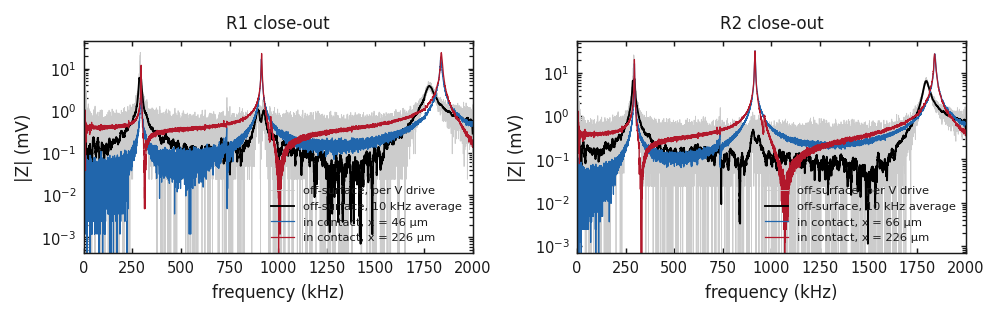

In [3]:
fig, axs = fp.figure("double", aspect=0.32, ncols=2)
for ax, (tag, o) in zip(axs, out.items()):
    f, B = o["f"], o["B"]
    k = 301; sm = np.convolve(B, np.ones(k) / k, "same")
    ax.semilogy(f / 1e3, np.abs(B) * 1e3, color="0.8", lw=0.4, label="off-surface, per V drive")
    ax.semilogy(f / 1e3, np.abs(sm) * 1e3, color="k", lw=0.9, label="off-surface, 10 kHz average")
    for j, c in ((0, fp.C["gp"]), (7, fp.C["ebgp"])):
        ax.semilogy(f / 1e3, np.abs(o["walk"].Z[0, j]) * 1e3, lw=0.6, color=c,
                    label=f"in contact, x = {o['walk'].x_clamp_um[j]:.0f} µm")
    ax.set_xlim(0, 2000); ax.set_xlabel("frequency (kHz)"); ax.set_ylabel("|Z| (mV)")
    ax.set_title(f"{tag.upper()} close-out"); ax.legend(fontsize=5.5)
fig.tight_layout(); fp.save(fig, "SIb_offsurface_vs_contact")

**Reading.** The off-surface spectrum is dominated by lock-in noise: its autocorrelation drops
to ~0.05 within 10 bins. Averaged over 10 kHz it keeps a small coherent part. That part is the
lifted lever itself, driven electrostatically by the tip bias: it has a free-resonance peak at
59–70 kHz and the same phase as the in-contact quasi-static response. It is not electrical
crosstalk in the detection chain. Scaled by drive to 1 V it would be 0.08–0.15 mV at 15–45 kHz,
several times larger than any domain-independent term actually present in contact (below).
**The close-out tunes are not a background reference.** A crosstalk reference needs the lever
unexcited: tip retracted by millimetres, or the drive routed into a dummy load.

## 2. Model-free test in contact: two domains × seven biases × eight positions

In [4]:
def background_test(s, band=(5e3, 1950e3), block=30):
    dec = domains.decompose_series(s, band=band)
    f = dec["freq_Hz"]; S = (dec["a1"] + dec["a2"]) / 2; b = dec["b"]; P = dec["P"]
    n = (f.size // block) * block
    blk = lambda A: A[..., :n].reshape(A.shape[0], -1, block).mean(-1)
    fb = f[:n].reshape(-1, block).mean(-1); Sb, bb, Pb = blk(S), blk(b), blk(P)
    Vs = np.linspace(0, 2.5, 251)
    cost = [np.sum(np.abs(Sb + V * bb - (Sb + V * bb).mean(0)) ** 2) for V in Vs]
    cost0 = [np.sum(np.abs(Sb + V * bb) ** 2) for V in Vs]
    V1 = Vs[int(np.argmin(cost))]; V0 = Vs[int(np.argmin(cost0))]
    Bf = (Sb + V1 * bb).mean(0)
    res = Sb + V1 * bb - Bf
    se = np.sqrt(np.mean(np.abs(res) ** 2, 0) / (Sb.shape[0] - 1))
    return dict(f=fb, B=Bf, se=se, P=Pb, b=bb, V_with_B=V1, V_without_B=V0,
                resid_with=min(cost) / np.sum(np.abs(Sb) ** 2), resid_without=min(cost0) / np.sum(np.abs(Sb) ** 2))

bt = {tag: background_test(F.load(f"scmpitB_{tag}_bias")) for tag in ("r1", "r2")}
rows = []
for tag, r in bt.items():
    for lo, hi in [(15e3, 45e3), (100e3, 250e3), (270e3, 320e3), (450e3, 800e3), (880e3, 950e3),
                   (1000e3, 1600e3), (1780e3, 1900e3)]:
        m = (r["f"] >= lo) & (r["f"] < hi)
        rows.append(dict(run=tag.upper(), band_kHz=f"{lo/1e3:.0f}-{hi/1e3:.0f}",
                         B_mV=np.median(abs(r["B"][m])) * 1e3, B_se_mV=np.median(r["se"][m]) * 1e3,
                         P_mV=np.median(abs(r["P"][:, m])) * 1e3,
                         B_over_P=np.median(abs(r["B"][m])) / np.median(abs(r["P"][:, m]))))
    print(f"{tag.upper()}: common V_cpd {r['V_with_B']:.2f} V with B(f), {r['V_without_B']:.2f} V without")
bgt = pd.DataFrame(rows); bgt.round(4)

R1: common V_cpd 0.84 V with B(f), 0.80 V without
R2: common V_cpd 1.05 V with B(f), 1.01 V without


,run,band_kHz,B_mV,B_se_mV,P_mV,B_over_P
0,R1,15-45,0.0095,0.0031,0.2226,0.0426
1,R1,100-250,0.0026,0.0023,0.3830,0.0067
2,R1,270-320,0.0315,0.0145,1.5829,0.0199
3,R1,450-800,0.0027,0.0027,0.2501,0.0109
4,R1,880-950,0.0152,0.0138,1.3329,0.0114
5,R1,1000-1600,0.0024,0.0038,0.2803,0.0085
6,R1,1780-1900,0.0064,0.0095,0.5308,0.0121
7,R2,15-45,0.0102,0.0026,0.2226,0.0460
8,R2,100-250,0.0020,0.0016,0.3779,0.0054
9,R2,270-320,0.0425,0.0078,2.2200,0.0192


[PosixPath('/home/claude/work/paper_analysis/figures/SIb_background_test.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/SIb_background_test.pdf')]

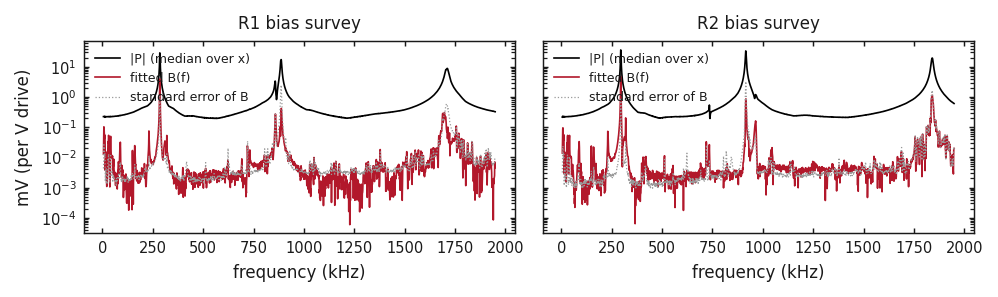

In [5]:
fig, axs = fp.figure("double", aspect=0.3, ncols=2, sharey=True)
for ax, (tag, r) in zip(axs, bt.items()):
    ax.semilogy(r["f"] / 1e3, np.median(abs(r["P"]), 0) * 1e3, color=fp.C["meas"], lw=0.8, label="|P| (median over x)")
    ax.semilogy(r["f"] / 1e3, abs(r["B"]) * 1e3, color=fp.C["ebgp"], lw=0.8, label="fitted B(f)")
    ax.semilogy(r["f"] / 1e3, r["se"] * 1e3, color="0.6", lw=0.6, ls=":", label="standard error of B")
    ax.set_xlabel("frequency (kHz)"); ax.set_title(f"{tag.upper()} bias survey"); ax.legend(fontsize=6)
axs[0].set_ylabel("mV (per V drive)")
fig.tight_layout(); fp.save(fig, "SIb_background_test")

**Result.** Across 100 kHz–1.9 MHz, a domain-, bias- and position-independent term is at most
0.5–2 % of the piezoresponse |P| on both campaigns, and usually within 1–2 standard errors of
zero. Near each resonance the fitted B tracks its standard error, which reflects small shifts
of the resonance between positions, not a background. The only clearly non-zero value is in
the quasi-static band (~4–5 % of |P|, 3–4σ). All of these are too small to account for a large
beam-model discrepancy. The shared
V_cpd barely moves (1.01 → 1.05 V R2, 0.80 → 0.84 V R1) when B is allowed.

**Consequence for the manuscript.**
- Remove the additive-background paragraph: the 99.5 % rank-1 SVD residual, the ~55° offset,
  "B accounts for ~3/4" and the retracted-tip proposal.
- Replace it with two statements. The phase offset was a conjugation defect, and bare EB on the
  corrected data is at ~3° phase error. A direct two-domain test on a second probe bounds any
  additive background at ≤ 2 % of |P|.
- Two-domain P = (a₁ − a₂)/2 cancels any domain-independent additive term exactly, so the d33
  values in notebook 06 are immune to B in any case.

In [6]:
results.save("si_background_test",
             dict(V_cpd={t: [r["V_with_B"], r["V_without_B"]] for t, r in bt.items()},
                  bands=bgt.to_dict("records")),
             table=bgt)

PosixPath('/home/claude/work/paper_analysis/results/si_background_test.json')